In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
from pathlib import Path
import tomllib
from loguru import logger
import csv
import regex as re

import seaborn as sns
import matplotlib.pyplot as plt

# --- Configuration ---
sns.set_theme(style="whitegrid", palette="muted")

In [60]:
# --- Load configuration and data ---
configfile = Path("../config.toml").resolve()
with configfile.open("rb") as f:
    config = tomllib.load(f)

datafile = (Path("..") / Path(config["processed"]) / config["current"]).resolve()
if not datafile.exists():
    logger.warning(
        "Datafile does not exist. Run src/preprocess.py first and check the timestamp!"
    )

df = pd.read_parquet(datafile)
df.columns

Index(['timestamp', 'message', 'author', 'has_emoji', 'is_topk',
       'message_length', 'has_link', 'timestamp_category', 'hour',
       'day_of_week', 'msg_length'],
      dtype='object')

In [61]:
# --- Load metadata ---
# meta data (test): nested_users5.json
# meta data (prod): resident_metadata.json

with open("resident_metadata.json", "r") as f:
    nested_users = json.load(f)

author_info_df = (
    pd.DataFrame(nested_users)
    .T
    .reset_index()
    .rename(columns={"index": "author"})
)

# author_info_df.columns
# author_info_df.head()

In [62]:
# --- Merge WhatsApp data with user info ---
df_merged = df.merge(author_info_df, on="author", how="left")

# --- Step 0: Exclude Board_function == "none" ---
df_merged = df_merged[df_merged["Board_function"].str.lower() != "not_applicable"]


# logger.info(f"Merged dataset has {len(df_merged)} messages from {df_merged['author'].nunique()} authors.")
print(f"Merged dataset has {len(df_merged)} messages from {df_merged['author'].nunique()} authors.")

df_merged.columns
# df_merged.head()

Merged dataset has 1678 messages from 9 authors.


Index(['timestamp', 'message', 'author', 'has_emoji', 'is_topk',
       'message_length', 'has_link', 'timestamp_category', 'hour',
       'day_of_week', 'msg_length', 'Name', 'Gender', 'Entrance_nr', 'Unit_nr',
       'Floor_nr', 'Nr_rooms', 'Board_function'],
      dtype='object')

In [63]:
def clean_message(text: str) -> str:
    """
    Cleans a message by removing links, newlines, and excess whitespace.

    Args:
        text (str): Original message text.

    Returns:
        str: Cleaned, lowercased version of the message.
    """
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)  # remove links
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [64]:
df_merged["clean_message"] = df_merged["message"].apply(clean_message)


In [65]:
# df_merged["word_count"] = (
#     df_merged["message"]
#     .fillna("")
#     .str.split()
#     .str.len()
# )

# df_merged 

In [66]:
df_merged["word_count"] = (
    df_merged["clean_message"]
    .str.split()
    .str.len()
)


In [67]:
emoji_pattern = re.compile(r"\p{Emoji}")

# df_merged["emoji_count"] = (
#     df_merged["message"]
#     .fillna("")
#     .apply(lambda x: len(emoji_pattern.findall(x)))
# )

df_merged["emoji_count"] = (
    df_merged["clean_message"]
    .apply(lambda x: len(emoji_pattern.findall(x)))
)

In [68]:
# df_by_author = (
#     df_merged
#     .groupby("author", as_index=False)
#     .agg(
#         message_count=("author", "size"),
#         Board_function=("Board_function", "first"),
#     )
# )


# df_by_author = (
#     df_merged
#     .groupby("author", as_index=False)
#     .agg(
#         message_count=("author", "size"),
#         Board_function=("Board_function", "first"),
#         #total_emojies=("emoji_count", "sum"),
#         messages_with_emojies=("has_emoji", "sum"),
#         total_words=("word_count", "sum")
#     )
# )

df_by_author = (
    df_merged
    .groupby("author", as_index=False)
    .agg(
        message_count=("author", "size"),
        Board_function=("Board_function", "first"),
        messages_with_emojies=("has_emoji", "sum"),
        total_words=("word_count", "sum"),
        total_emojis=("emoji_count", "sum"),
    )
)


In [69]:
# df_by_author.count()
# df_by_author.info()
# df_by_author


In [70]:
# optie 1: percentage messages with emojies
df_by_author["percentage_messages_with_emojies"] = (
    df_by_author["messages_with_emojies"]
    / df_by_author["message_count"]
    * 100
)

# optie 2: Emoji’s per 100 woorden 
# df_by_author["emojis_per_100_words"] = (
#     df_by_author["total_emojis"] / df_by_author["total_words"] * 100
# ).round(2)


In [71]:
# df_by_author["emojis_per_100_words"] = (
#     df_by_author["total_emojis"]
#     .div(df_by_author["total_words"].replace(0, pd.NA))
#     * 100
# ).round(2)


In [72]:
df_by_author["percentage_messages_with_emojies"] = (
    df_by_author["percentage_messages_with_emojies"].round(2)
)


df_by_author.sort_values(by="percentage_messages_with_emojies", ascending=False, inplace=True)
df_by_author

# df_by_author[
#     ["author", "message_count", "total_words", "total_emojis", "emojis_per_100_words"]
# ].sort_values("emojis_per_100_words", ascending=False)


,author,message_count,Board_function,messages_with_emojies,total_words,total_emojis,percentage_messages_with_emojies
7,vivid-rhinoceros,236,Commissielid 1,101,4841,809,42.80
5,peppy-rat,47,Secretaris,19,555,140,40.43
1,cheerful-boar,20,Penningmeester,7,395,76,35.00
0,cackling-eland,106,Bestuurslid 1,26,2223,567,24.53
8,zany-trout,108,Commissielid 2,23,1991,604,21.30
4,limber-ostrich,160,Bestuurslid 3,22,1542,581,13.75
2,goofy-tiger,24,Bestuurslid 2,2,688,87,8.33
6,sudsy-jellyfish,195,Commissielid 3,16,2678,764,8.21
3,intense-toad,782,Voorzitter,42,17849,2694,5.37


In [73]:
df_by_function = (
    df_by_author
    .groupby("Board_function", as_index=False)
    .agg(
        total_messages=("message_count", "sum"),
        total_messages_with_emojis=("messages_with_emojies", "sum"),
    )
)

df_by_function["percentage_messages_with_emojies"] = (
    df_by_function["total_messages_with_emojis"]
    / df_by_function["total_messages"]
    * 100
).round(2)

df_by_function.sort_values(
    "percentage_messages_with_emojies", ascending=False, inplace=True
)


In [74]:
max_value = df_by_function["percentage_messages_with_emojies"].max()
max_function = df_by_function.loc[
    df_by_function["percentage_messages_with_emojies"] == max_value,
    "Board_function"
].iloc[0]


In [75]:
# # --- Prepare data for plotting ---
# df_plot = df_by_author.sort_values(
#     "percentage_messages_with_emojies", ascending=False
# )

# # Identify highest value
# max_value = df_plot["percentage_messages_with_emojies"].max()
# max_author = df_plot.loc[
#     df_plot["percentage_messages_with_emojies"] == max_value, "author"
# ].iloc[0]

# # Create color list: red for max, navy for others
# colors = [
#     "red" if author == max_author else "navy"
#     for author in df_plot["author"]
# ]

# # --- Plot ---
# plt.figure(figsize=(12, 6))

# ax = sns.barplot(
#     data=df_plot,
#     x="author",
#     y="percentage_messages_with_emojies",
#     palette=colors
# )

# ax.set_title("Percentage of Messages Containing Emojis per Author", fontsize=14)
# ax.set_xlabel("Author")
# ax.set_ylabel("Percentage of Messages with Emojis (%)")

# plt.xticks(rotation=45, ha="right")

# # Annotate highest bar
# ax.text(
#     0,
#     max_value + 1,
#     f"Highest: {max_author}\n({max_value}%)",
#     ha="center",
#     va="bottom",
#     color="red",
#     fontweight="bold"
# )

# plt.tight_layout()
# plt.show()


/var/folders/hv/m4f2vdm11q911kmp31zcg4t40000gn/T/ipykernel_33679/691341533.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


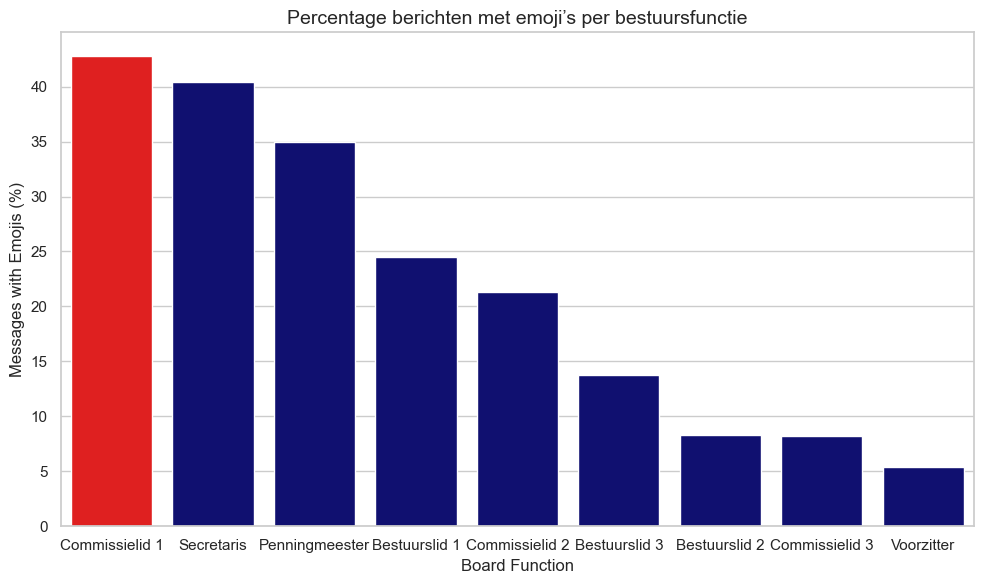

In [78]:
# Colors: red for highest, navy for others
colors = [
    "red" if func == max_function else "navy"
    for func in df_by_function["Board_function"]
]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_by_function,
    x="Board_function",
    y="percentage_messages_with_emojies",
    palette=colors
)

ax.set_title(
    "Percentage berichten met emoji’s per bestuursfunctie",
    fontsize=14
)
ax.set_xlabel("Board Function")
ax.set_ylabel("Messages with Emojis (%)")

# Annotate highest bar
# ax.text(
#     0,
#     max_value + 1,
#     f"Highest: {max_function}\n({max_value}%)",
#     ha="center",
#     va="bottom",
#     color="red",
#     fontweight="bold"
# )

plt.tight_layout()
plt.show()
